# Simplicial Complexes
## From metric spaces to topological spaces

Given a finite metric space $(X, d)$, a **simplicial complex** is a combinatorial structure that encodes the topological relationships between points. It is the bridge between raw data and homology.

The metric $d$ need not be Euclidean — in financial applications, correlation-based or covariance-derived metrics are natural choices that carry meaningful geometric information.

## Key Concepts

- **$k$-simplex** — the convex hull of $k+1$ affinely independent points. A 0-simplex is a point, a 1-simplex an edge, a 2-simplex a triangle, a 3-simplex a tetrahedron.
- **Simplicial complex** — a collection $K$ of simplices closed under taking faces: if $\sigma \in K$ and $\tau \subseteq \sigma$ then $\tau \in K$
- **Vietoris-Rips complex** $VR(X, \varepsilon)$ — the simplicial complex whose $k$-simplices are $(k+1)$-subsets of $X$ with pairwise distances $< \varepsilon$

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

## Vietoris-Rips Construction

We construct $VR(X, \varepsilon)$ explicitly for a small point cloud at increasing values of $\varepsilon$, illustrating how the complex grows as the scale parameter increases.

This manual construction makes transparent what TDA libraries compute automatically — and clarifies the relationship between pairwise distances and simplicial structure.

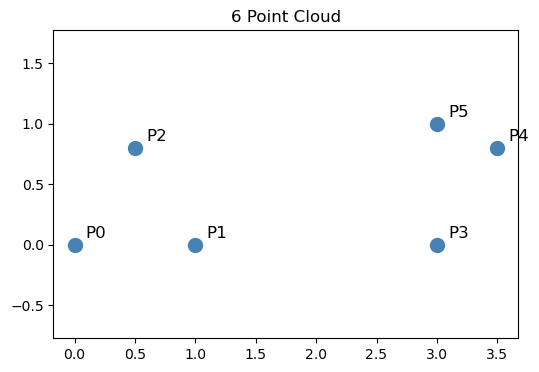

In [28]:
# A small point cloud — 6 points in 2D
points = np.array([
    [0, 0],
    [1, 0],
    [0.5, 0.8],
    [3, 0],
    [3.5, 0.8],
    [3, 1]
])

# Visualize the points
plt.figure(figsize=(6, 4))
plt.scatter(points[:, 0], points[:, 1], c='steelblue', s=100, zorder=3)

# Label each point
for i, p in enumerate(points):
    plt.annotate(f'P{i}', p, textcoords="offset points", xytext=(8, 5), fontsize=12)

plt.title("6 Point Cloud")
plt.axis('equal')
plt.show()

In [29]:
# Compute pairwise distances
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Print all pairwise distances
for i, j in combinations(range(len(points)), 2):
    d = euclidean_distance(points[i], points[j])
    print(f"P{i} — P{j}: {d:.3f}")

P0 — P1: 1.000
P0 — P2: 0.943
P0 — P3: 3.000
P0 — P4: 3.590
P0 — P5: 3.162
P1 — P2: 0.943
P1 — P3: 2.000
P1 — P4: 2.625
P1 — P5: 2.236
P2 — P3: 2.625
P2 — P4: 3.000
P2 — P5: 2.508
P3 — P4: 0.943
P3 — P5: 1.000
P4 — P5: 0.539


In [30]:
epsilon = 1.01

# Find all edges (1-simplices)
edges = []
for i, j in combinations(range(len(points)), 2):
    d = euclidean_distance(points[i], points[j])
    if d < epsilon:
        edges.append((i, j))

print("Edges found:")
for e in edges:
    print(f"  P{e[0]} — P{e[1]}")

Edges found:
  P0 — P1
  P0 — P2
  P1 — P2
  P3 — P4
  P3 — P5
  P4 — P5


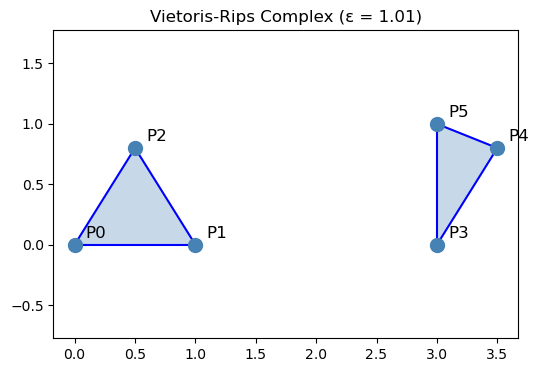

In [31]:
epsilon = 1.01

# Find edges
edges = []
for i, j in combinations(range(len(points)), 2):
    if euclidean_distance(points[i], points[j]) < epsilon:
        edges.append((i, j))

# Find triangles (2-simplices)
triangles = []
for i, j, k in combinations(range(len(points)), 3):
    if (euclidean_distance(points[i], points[j]) < epsilon and
        euclidean_distance(points[i], points[k]) < epsilon and
        euclidean_distance(points[j], points[k]) < epsilon):
        triangles.append((i, j, k))

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))

# Draw triangles
for t in triangles:
    triangle = plt.Polygon(points[list(t)], alpha=0.3, color='steelblue')
    ax.add_patch(triangle)

# Draw edges
for e in edges:
    ax.plot(points[list(e), 0], points[list(e), 1], 'b-', zorder=2)

# Draw points
ax.scatter(points[:, 0], points[:, 1], c='steelblue', s=100, zorder=3)
for i, p in enumerate(points):
    ax.annotate(f'P{i}', p, textcoords="offset points", xytext=(8, 5), fontsize=12)

ax.set_title(f"Vietoris-Rips Complex (ε = {epsilon})")
ax.axis('equal')
plt.show()

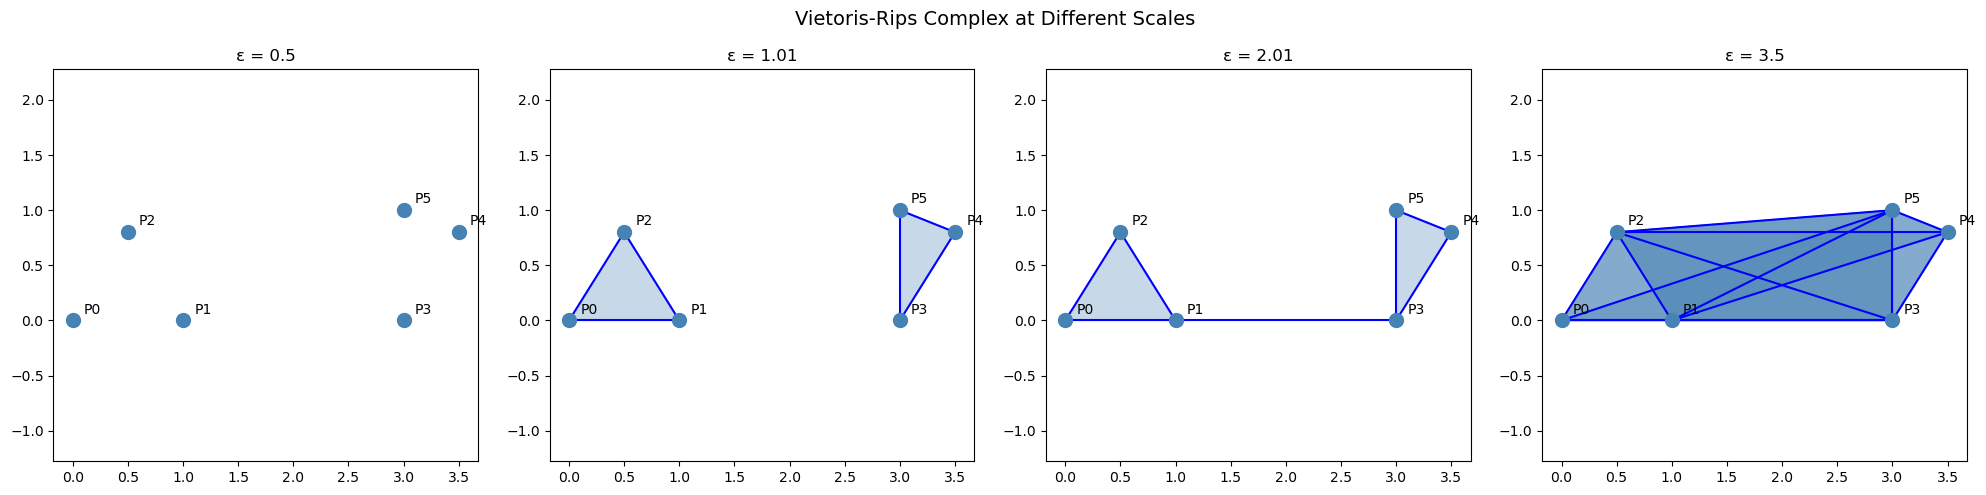

In [32]:
epsilons = [0.5, 1.01, 2.01, 3.5]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, eps in zip(axes, epsilons):
    edges = [(i,j) for i,j in combinations(range(len(points)), 2) 
             if euclidean_distance(points[i], points[j]) < eps]
    
    triangles = [(i,j,k) for i,j,k in combinations(range(len(points)), 3)
                 if all(euclidean_distance(points[a], points[b]) < eps 
                        for a,b in combinations([i,j,k], 2))]
    
    for t in triangles:
        ax.add_patch(plt.Polygon(points[list(t)], alpha=0.3, color='steelblue'))
    for e in edges:
        ax.plot(points[list(e), 0], points[list(e), 1], 'b-', zorder=2)
    
    ax.scatter(points[:, 0], points[:, 1], c='steelblue', s=100, zorder=3)
    for i, p in enumerate(points):
        ax.annotate(f'P{i}', p, textcoords="offset points", xytext=(8,5), fontsize=10)
    
    ax.set_title(f"ε = {eps}")
    ax.axis('equal')

plt.suptitle("Vietoris-Rips Complex at Different Scales", fontsize=14)
plt.tight_layout()
plt.show()

## Vietoris-Rips Filtration

Given a point cloud $X$ and a scale parameter $\varepsilon > 0$, the Vietoris-Rips complex $VR(X, \varepsilon)$ is the simplicial complex whose $k$-simplices are $(k+1)$-subsets of $X$ with pairwise distances $< \varepsilon$.

The **filtration** is the nested sequence:

$$VR(X, \varepsilon_1) \subseteq VR(X, \varepsilon_2) \subseteq \cdots \subseteq VR(X, \varepsilon_n)$$

Persistent homology tracks the birth and death of homological features across this filtration.

## Observations

- **ε = 0.5** — only isolated points, no edges formed yet
- **ε = 1.01** — two disjoint 2-simplices (triangles), two connected components (H0 = 2)
- **ε = 2.01** — the two components merge via an edge, H0 drops to 1
- **ε = 3.5** — a single connected complex, higher order simplices appear

The death of the second H0 generator occurs precisely when the two components merge — this birth-death pair will appear in the persistence diagram as a dot with birth ≈ 0 and death ≈ 2.

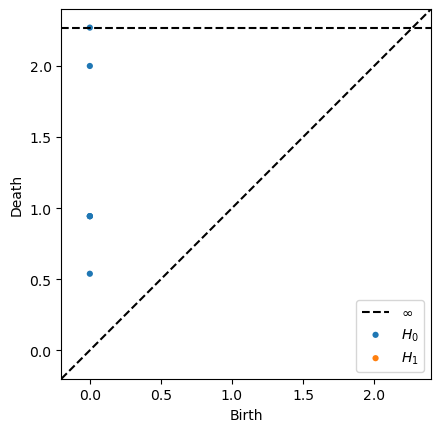

In [26]:
from ripser import ripser
from persim import plot_diagrams

diagrams = ripser(points)['dgms']
plot_diagrams(diagrams, show=True)

## Conclusions

The persistence diagram confirms our geometric intuition:

- **4 H0 generators** — each corresponding to a connected component at birth
- **3 die at finite ε** — as points connect within and between groups
- **1 persists to ∞** — the final single connected component
- **No persistent H1** — no loops in the Vietoris-Rips complex at any scale

The birth-death pair dying at ε ≈ 2 precisely captures the merging of the two triangles — a topological event that is invisible to standard clustering methods but trivially detected by persistent homology.